# Feature Engineering

A major bottleneck in production ML is **training-serving skew**—the discrepancy between how features are calculated during model training versus how they are queried at inference time. To solve this, we use **Feast** as our Feature Store.

## Key Feast Concepts in this Project

1. **Entity**: The primary key. Here, the `pickup_location_id` represents a taxi zone.
2. **Data Source**: The source of truth for features. We define a batch file source pointing to our offline parquet file: `data/processed/hourly_demand_features.parquet`.
3. **Feature View**: Maps features to entities and defines metadata (schema, TTL, and data source).

## Offline & Online Stores
Feast handles two databases under the hood:
- **Offline Store (DuckDB)**: Optimized for analytical queries. Used during training to perform point-in-time joins and retrieve historical feature records.
- **Online Store (SQLite)**: Optimized for fast, low-latency lookups. Materialized features are loaded here for real-time predictions.

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd

# Load feature data from the processed parquet destination
features_path = "../data/processed/hourly_demand_features.parquet"
df = pd.read_parquet(features_path)
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"])
print(f"Loaded {len(df)} feature rows. Columns:")
df.head()

Loaded 71253 feature rows. Columns:


,pickup_location_id,event_timestamp,pickup_count,hour,day_of_week,is_weekend,month
0,1,2022-10-24 17:00:00,1,17,0,False,10
1,1,2022-10-25 03:00:00,1,3,1,False,10
2,1,2023-01-01 05:00:00,1,5,6,True,1
3,1,2023-01-01 08:00:00,1,8,6,True,1
4,1,2023-01-01 11:00:00,1,11,6,True,1


## Visualize Taxi Pickups Over Time
Let's look at the average demand curve across hours of the day.

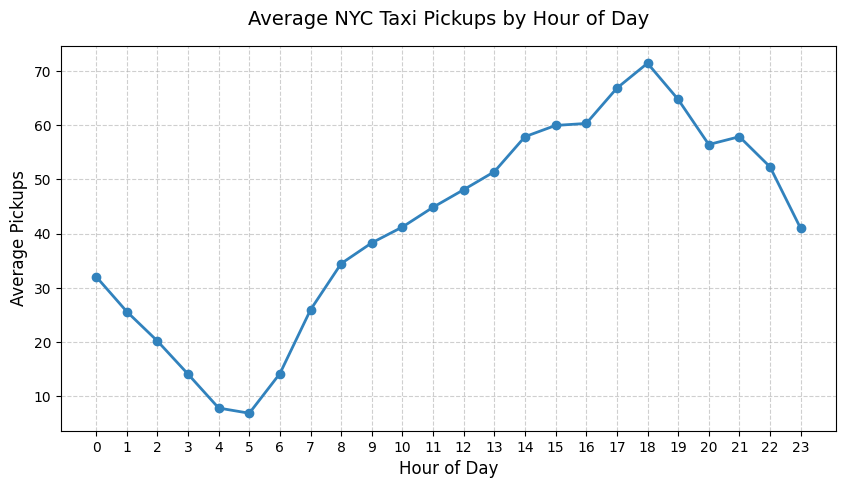

In [2]:
hourly_avg = df.groupby("hour")["pickup_count"].mean()

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o",
    color="#3182bd",
    linewidth=2,
)
plt.title("Average NYC Taxi Pickups by Hour of Day", fontsize=14, pad=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Pickups", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(24))
plt.show()

## Interactive Zone Explorer
Use this interactive widget to inspect features for a specific pickup zone location ID.

In [3]:
unique_zones = sorted(df["pickup_location_id"].unique())
zone_select = widgets.Dropdown(
    options=[str(z) for z in unique_zones[:30]],
    value=str(unique_zones[0]),
    description="Location ID:",
    disabled=False,
)


def plot_zone_demand(zone_id):
    zone_df = df[df["pickup_location_id"] == zone_id].sort_values(
        "event_timestamp"
    )
    if zone_df.empty:
        print("No records found for this location.")
        return

    # Plot pickups for the first week of the month
    sample_df = zone_df.head(168)  # 24 * 7
    plt.figure(figsize=(12, 4))
    plt.plot(
        sample_df["event_timestamp"],
        sample_df["pickup_count"],
        color="#e6550d",
        label=f"Zone {zone_id}",
    )
    plt.title(
        f"Hourly Taxi Pickups for Location ID {zone_id} (First 7 Days)",
        fontsize=13,
    )
    plt.xlabel("Timestamp", fontsize=11)
    plt.ylabel("Pickups", fontsize=11)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Precompute all outputs for the 30 zones client-side
plot_outputs = []
for zone_id in unique_zones[:30]:
    out = widgets.Output()
    with out:
        plot_zone_demand(zone_id)
    plot_outputs.append(out)

stack = widgets.Stack(children=plot_outputs, selected_index=0)
widgets.jslink((zone_select, "index"), (stack, "selected_index"))

widgets.VBox([zone_select, stack])